In [2]:
# Import necessary library
import numpy as np

# Define the path to the .npy file
dataPath = "/Users/wachiii/Workschii/brain-asd/data_children/rawData/asd/CASD01.npy"

# Load the .npy file
data = np.load(dataPath)

# Display basic information about the data
print("Data Shape:", data.shape)
print("Data Length:", len(data))
print("First 10 Elements:", data[:10])

Data Shape: (20, 119552)
Data Length: 20
First 10 Elements: [[  8.35063706  11.35086595  13.65104143 ...   8.25062943   9.1506981
    7.95060655]
 [  5.95045396   7.55057603  10.55080491 ... -14.35109483 -14.25108721
  -12.25093462]
 [ -1.45011063  -1.25009537  -0.65004959 ... -17.75135424 -21.55164416
  -22.95175097]
 ...
 [  9.75074388   5.95045396   2.95022507 ... -32.35246815 -33.95259022
  -34.25261311]
 [  4.65035477   7.25055314  10.95083543 ...  -3.85029374  -2.25017166
   -0.75005722]
 [ 12.5509575   19.55149157  24.45186542 ...  18.55141527  27.4520943
   26.85204852]]


In [55]:
# Import necessary library
import pyedflib

# Define the path to the EDF file
edf_path = "/Users/wachiii/Workschii/brain-asd/temp/Cybathlon2024_BrainRacing/cbttest(9), start 15.00 11.001.01  EO.edf"

# Load the EDF file
edf_file = pyedflib.EdfReader(edf_path)

# Get basic information about the EDF file
n_signals = edf_file.signals_in_file
signal_labels = edf_file.getSignalLabels()
sample_frequencies = edf_file.getSampleFrequencies()

print("Number of Signals:", n_signals)
print("Signal Labels:", signal_labels)
print("count labels:", len(signal_labels))
print("Sample Frequencies:", sample_frequencies)

# Get the shape of the data for the first signal
signal_data = edf_file.readSignal(0)
print("Shape of First Signal Data:", signal_data.shape)
print("First 10 Data Points of First Signal:", signal_data[:10])

# Close the EDF file
edf_file.close()

Number of Signals: 20
Signal Labels: ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1']
count labels: 20
Sample Frequencies: [256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256.
 256. 256. 256. 256. 256. 256.]
Shape of First Signal Data: (330240,)
First 10 Data Points of First Signal: [-5.00038148e-02 -1.85014115e+00 -1.26509651e+01 -5.27540246e+01
 -1.54461784e+02 -3.39775921e+02 -5.80594293e+02 -7.80509545e+02
 -8.11111879e+02 -5.94495354e+02]


In [56]:
t = 330240/256
t


1290.0

In [57]:
t/60

21.5

In [3]:
# Import necessary library
import pyedflib

# Define the path to the EDF file
edf_path = "/Users/wachiii/Workschii/brain-asd/EDF ASD.edf"

# Load the EDF file
edf_file = pyedflib.EdfReader(edf_path)

# Get basic information about the EDF file
n_signals = edf_file.signals_in_file
signal_labels = edf_file.getSignalLabels()
sample_frequencies = edf_file.getSampleFrequencies()

print("Number of Signals:", n_signals)
print("Signal Labels:", signal_labels)
print("Count of Labels:", len(signal_labels))
print("Sample Frequencies:", sample_frequencies)

# Check for annotations (triggers)
annotations = edf_file.readAnnotations()
if annotations[0].size > 0:
    print("Annotations (Triggers) Found:")
    for onset, duration, description in zip(*annotations):
        print(f"Onset: {onset}, Duration: {duration}, Description: {description}")
else:
    print("No Annotations (Triggers) Found.")

# Get the shape of the data for the first signal
signal_data = edf_file.readSignal(0)
print("Shape of First Signal Data:", signal_data.shape)
print("First 10 Data Points of First Signal:", signal_data[:10])

# Close the EDF file
edf_file.close()

Number of Signals: 20
Signal Labels: ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1']
Count of Labels: 20
Sample Frequencies: [256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256. 256.
 256. 256. 256. 256. 256. 256.]
No Annotations (Triggers) Found.
Shape of First Signal Data: (119552,)
First 10 Data Points of First Signal: [ 8.35063706 11.35086595 13.65104143 15.05114824 15.75120165 16.45125505
 18.15138476 21.25162127 24.85189593 27.4520943 ]


In [19]:
# Import necessary libraries
import os
import pyedflib
import numpy as np

# Define the input directory containing .edf files
input_dir = "/Users/wachiii/Workschii/brain-asd/adult_edf_hc"

# Define the output directory for .npy files
output_dir = "/Users/wachiii/Workschii/brain-asd/adult_hc_npy"
os.makedirs(output_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Loop through all files in the input directory
for file_name in os.listdir(input_dir):
    if file_name.endswith(".edf"):  # Process only .edf files
        edf_path = os.path.join(input_dir, file_name)
        npy_path = os.path.join(output_dir, file_name.replace(".edf", ".npy"))
        
        print(f"Processing file: {edf_path}")
        
        # Load the EDF file
        edf_file = pyedflib.EdfReader(edf_path)
        n_signals = edf_file.signals_in_file
        
        # Read all signals and store them in a NumPy array
        signals = np.array([edf_file.readSignal(i) for i in range(n_signals)])
        
        # Save the signals to a .npy file
        np.save(npy_path, signals)
        print(f"Saved to: {npy_path}")
        
        # Close the EDF file
        edf_file.close()

print("Conversion completed!")

Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo02.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo02.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo06.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo06.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo07.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo07.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo05.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo05.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo04.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo04.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo01 EC.edf
Saved to: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/anceceo01 EC.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_edf_hc/anceceo03 EC.edf
Saved 

In [42]:
# Import necessary libraries
import os
import numpy as np

# Define the input directory containing .npy files
input_dir = "/Users/wachiii/Workschii/brain-asd/adult_hc_npy"

# Define the output directory for the split .npy files
output_dir = "/Users/wachiii/Workschii/brain-asd/adult_hc_split"
os.makedirs(output_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Define the number of samples for the first 2 minutes (Eye Close)
SFREQ = 256  # Sampling frequency (samples per second)
EYE_CLOSE_SAMPLES = SFREQ * 60 * 2  # 2 minutes of data

# Loop through all files in the input directory
for file_name in os.listdir(input_dir):
    if file_name.endswith(".npy"):  # Process only .npy files
        npy_path = os.path.join(input_dir, file_name)
        base_name = os.path.splitext(file_name)[0]  # Get the file name without extension
        
        print(f"Processing file: {npy_path}")
        
        # Load the .npy file
        signals = np.load(npy_path)
        
        # Split the data into Eye Close (first 2 minutes) and Eye Open (remaining)
        eye_close_data = signals[:, :EYE_CLOSE_SAMPLES]
        eye_open_data = signals[:, EYE_CLOSE_SAMPLES:]
        
        # Save the Eye Close data
        ec_npy_path = os.path.join(output_dir, f"{base_name}_EC.npy")
        np.save(ec_npy_path, eye_close_data)
        print(f"Saved Eye Close data to: {ec_npy_path}")
        
        # Save the Eye Open data
        eo_npy_path = os.path.join(output_dir, f"{base_name}_EO.npy")
        np.save(eo_npy_path, eye_open_data)
        print(f"Saved Eye Open data to: {eo_npy_path}")

print("Processing and splitting completed!")

Processing file: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/H06.npy
Saved Eye Close data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H06_EC.npy
Saved Eye Open data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H06_EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/H07.npy
Saved Eye Close data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H07_EC.npy
Saved Eye Open data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H07_EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/H05.npy
Saved Eye Close data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H05_EC.npy
Saved Eye Open data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H05_EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/adult_hc_npy/H04.npy
Saved Eye Close data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H04_EC.npy
Saved Eye Open data to: /Users/wachiii/Workschii/brain-asd/adult_hc_split/H04_EO.npy
Processing file: /Users/

In [45]:
# Import necessary libraries
import os
import pyedflib
import numpy as np

# Define the input directory containing .edf files
input_dir = "/Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing"

# Define the output directory for .npy files
output_dir = "/Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy"
os.makedirs(output_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Loop through all files in the input directory
for file_name in os.listdir(input_dir):
    if file_name.endswith(".edf"):  # Process only .edf files
        edf_path = os.path.join(input_dir, file_name)
        npy_path = os.path.join(output_dir, file_name.replace(".edf", ".npy"))
        
        print(f"Processing file: {edf_path}")
        
        # Load the EDF file
        edf_file = pyedflib.EdfReader(edf_path)
        n_signals = edf_file.signals_in_file
        
        # Read all signals and store them in a NumPy array
        signals = np.array([edf_file.readSignal(i) for i in range(n_signals)])
        
        # Save the signals to a .npy file
        np.save(npy_path, signals)
        print(f"Saved to: {npy_path}")
        
        # Close the EDF file
        edf_file.close()

print("Conversion completed!")

Processing file: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing/cbttest(9), start 15.00 11.001.01  EO.edf
Saved to: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy/cbttest(9), start 15.00 11.001.01  EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing/cbttest(10), start 9.40 12.001.01  EO.edf
Saved to: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy/cbttest(10), start 9.40 12.001.01  EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing/cbttest(8), start 41.00 10.001.01  EO.edf
Saved to: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy/cbttest(8), start 41.00 10.001.01  EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing/cbttest(4), start 15.00 06.001.01  EO.edf
Saved to: /Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy/cbttest(4), start 15.00 06.001.01  EO.npy
Processing file: /Users/wachiii/Workschii/brain-asd/

In [70]:
# Import necessary libraries
import os
import numpy as np

def process_npy_file(npy_path, x, output_dir="/Users/wachiii/Workschii/brain-asd/teee"):
    """
    Process a .npy file by removing data from 0 to x seconds and saving the result.

    Parameters:
        npy_path (str): Path to the input .npy file.
        x (int): Time in seconds to remove from the start of the file.
        output_dir (str): Directory to save the processed .npy file.
    """
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Calculate the number of samples to skip
    SFREQ = 256  # Sampling frequency (samples per second)
    samples_to_skip = x * SFREQ

    # Load the .npy file
    signals = np.load(npy_path)

    # Remove the first `samples_to_skip` samples
    processed_signals = signals[:, samples_to_skip:]

    # Define the output file path
    base_name = os.path.basename(npy_path)
    output_path = os.path.join(output_dir, base_name)

    # Save the processed signals to a new .npy file
    np.save(output_path, processed_signals)
    print(f"Processed file saved to: {output_path}")

# Example usage
npy_path = "/Users/wachiii/Workschii/brain-asd/Cybathlon2024_BrainRacing_npy/cbttest(11), start 14.40 13.001.01  EO.npy"  # Replace with the path to your .npy file
x = 14*60  # Replace with the number of seconds to skip
process_npy_file(npy_path, x)

Processed file saved to: /Users/wachiii/Workschii/brain-asd/teee/cbttest(11), start 14.40 13.001.01  EO.npy


In [71]:
# Import necessary libraries
import os
import numpy as np

def process_files(input_dir, output_dir, sfreq=256, segment_duration=30):
    """
    Process .npy files in the input directory by splitting them into segments
    of alternating Eye Open (EO) and Eye Close (EC) data, and save the results
    in the output directory.

    Parameters:
        input_dir (str): Directory containing the input .npy files.
        output_dir (str): Directory to save the processed .npy files.
        sfreq (int): Sampling frequency (samples per second).
        segment_duration (int): Duration of each segment in seconds.
    """
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Calculate the number of samples per segment
    samples_per_segment = sfreq * segment_duration

    # Loop through all files in the input directory
    for file_name in os.listdir(input_dir):
        if file_name.endswith(".npy"):  # Process only .npy files
            npy_path = os.path.join(input_dir, file_name)
            base_name = os.path.splitext(file_name)[0]  # Get the file name without extension
            
            print(f"Processing file: {npy_path}")
            
            # Load the .npy file
            signals = np.load(npy_path)
            
            # Process the first 4 segments (30s EO, 30s EC, 30s EO, 30s EC)
            for i in range(4):
                start_idx = i * samples_per_segment
                end_idx = (i + 1) * samples_per_segment
                segment_data = signals[:, start_idx:end_idx]
                
                # Determine the label (EO or EC) and segment number
                label = "EO" if i % 2 == 0 else "EC"
                segment_number = (i // 2) + 1
                
                # Define the output file path
                output_file_name = f"{base_name}_{label}_{segment_number}.npy"
                output_path = os.path.join(output_dir, output_file_name)
                
                # Save the segment data
                np.save(output_path, segment_data)
                print(f"Saved segment to: {output_path}")

print("Processing completed!")

# Example usage
input_dir = "/Users/wachiii/Workschii/brain-asd/teee"  # Directory containing the input .npy files
output_dir = "/Users/wachiii/Workschii/brain-asd/processed_teee"  # Directory to save the processed files
process_files(input_dir, output_dir)

Processing completed!
Processing file: /Users/wachiii/Workschii/brain-asd/teee/H09.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H09_EO_1.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H09_EC_1.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H09_EO_2.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H09_EC_2.npy
Processing file: /Users/wachiii/Workschii/brain-asd/teee/H08.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H08_EO_1.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H08_EC_1.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H08_EO_2.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H08_EC_2.npy
Processing file: /Users/wachiii/Workschii/brain-asd/teee/H12.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/processed_teee/H12_EO_1.npy
Saved segment to: /Users/wachiii/Workschii/brain-asd/p

In [74]:
for fileName in os.listdir(whichNumpyDirPath):
    if fileName.endswith(".npy"):  
        filePath = os.path.join(whichNumpyDirPath, fileName)
        print(f"Processing file: {filePath}")
        eegData = np.load(filePath)

        chNames = [f"Ch{i+1}" for i in range(eegData.shape[0])]  
        chTypes = ["eeg"] * eegData.shape[0] 
        info = mne.create_info(ch_names=chNames, sfreq=DATASET_SFREQ, ch_types=chTypes)
        raw = mne.io.RawArray(eegData, info)
        raw.filter(l_freq=0.5, h_freq=40, fir_design='firwin')
        raw.notch_filter(freqs=50, fir_design='firwin')

        # Calculate the event interval and ensure there is enough data
        event_interval = int(raw.info['sfreq'] * EPOCH_LENGTH / 2)
        min_samples_for_epoch = int(raw.info['sfreq'] * EPOCH_LENGTH)

        if raw.n_times >= min_samples_for_epoch:
            events = np.array(
                [[i, 0, 1] for i in range(0, raw.n_times - min_samples_for_epoch, event_interval)],
                dtype=int
            )
            eventId = {"Dummy": 1}

            tmin = 0
            tmax = EPOCH_LENGTH - 1 / raw.info['sfreq']  
            print(f"Creating {EPOCH_LENGTH}-second epochs with 50% overlap...")
            epochs = mne.Epochs(raw, events, eventId, tmin=tmin, tmax=tmax, baseline=None, preload=True)
            print(f"Epochs shape (n_epochs, n_channels, n_times): {epochs.get_data().shape}")
            
            os.makedirs(toSaveDirPath, exist_ok=True)
            epoch_file = os.path.join(toSaveDirPath, fileName.replace(".npy", ".fif"))
            epochs.save(epoch_file, overwrite=True)
            print(f"Saved epochs to: {epoch_file}")
        else:
            print(f"Not enough data in {fileName} to create an epoch.")

NameError: name 'whichNumpyDirPath' is not defined

In [77]:
# Import necessary library
import numpy as np

def inspect_npy_file(file_path):
    """
    Inspect a .npy file and display basic information about its content.

    Parameters:
        file_path (str): Path to the .npy file.
    """
    # Load the .npy file
    data = np.load(file_path)

    # Display basic information about the data
    print(f"File: {file_path}")
    print("Data Shape:", data.shape)
    print("Data Type:", data.dtype)
    print("Data Length:", len(data))
    print("First 10 Elements (if applicable):")
    print(data[:10] if data.ndim == 1 else data[:, :10])

# Example usage
file_path = "/Users/wachiii/Workschii/brain-asd/temp/processed_teee/H11_EC_1.npy"  # Replace with the path to your .npy file
inspect_npy_file(file_path)

File: /Users/wachiii/Workschii/brain-asd/temp/processed_teee/H11_EC_1.npy
Data Shape: (20, 7680)
Data Type: float64
Data Length: 20
First 10 Elements (if applicable):
[[ 2.45018692  0.45003433 -1.350103   -2.45018692 -2.25017166 -0.85006485
   0.65004959  1.45011063  0.85006485 -0.55004196]
 [-3.0502327  -3.85029374 -3.75028611 -2.65020218 -0.65004959  1.350103
   2.75020981  2.95022507  1.95014878  0.55004196]
 [-2.95022507 -3.45026322 -4.15031662 -4.65035477 -4.15031662 -2.15016403
   0.55004196  2.95022507  4.050309    3.35025559]
 [-3.55027085 -2.85021744 -1.65012589  0.05000381  1.95014878  4.15031662
   6.05046159  6.85052262  6.35048447  4.65035477]
 [ 7.55057603  4.35033188  1.05008011 -1.05008011 -1.350103    0.05000381
   1.75013352  2.75020981  2.45018692  1.25009537]
 [ 3.35025559  3.0502327   0.45003433 -2.75020981 -4.55034714 -3.55027085
  -0.15001144  3.35025559  5.15039292  4.15031662]
 [ 1.25009537  1.75013352  2.95022507  5.05038529  7.35056077  9.1506981
   9.8507515

In [2]:
# Import necessary library
import numpy as np

def inspect_npy_length(file_path, sfreq=256):
    """
    Inspect the length of a .npy file in seconds.

    Parameters:
        file_path (str): Path to the .npy file.
        sfreq (int): Sampling frequency (samples per second). Default is 256 Hz.
    """
    # Load the .npy file
    data = np.load(file_path)

    # Calculate the length in seconds
    if data.ndim == 2:  # Assuming the data is in (channels, samples) format
        n_samples = data.shape[1]
    elif data.ndim == 1:  # If the data is 1D
        n_samples = data.shape[0]
    else:
        print("Unexpected data format.")
        return

    length_in_seconds = n_samples / sfreq

    # Display the results
    print(f"File: {file_path}")
    print(f"Data Shape: {data.shape}")
    print(f"Sampling Frequency: {sfreq} Hz")
    print(f"Length: {length_in_seconds:.2f} seconds")
    print(f"minutes: {length_in_seconds / 60:.2f} minutes")

# Example usage
file_path = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/asd/CASD02.npy"  # Replace with the path to your .npy file
inspect_npy_length(file_path)

File: /Users/wachiii/Workschii/brain-asd/data/data_children/rawData/asd/CASD02.npy
Data Shape: (20, 117504)
Sampling Frequency: 256 Hz
Length: 459.00 seconds
minutes: 7.65 minutes


In [4]:
# Import necessary libraries
import os
import numpy as np

def print_file_lengths_in_minutes(directory, sfreq=256):
    """
    Loop through all .npy files in a directory and print their lengths in minutes.

    Parameters:
        directory (str): Path to the directory containing .npy files.
        sfreq (int): Sampling frequency (samples per second). Default is 256 Hz.
    """
    print(f"Processing directory: {directory}")
    for file_name in os.listdir(directory):
        if file_name.endswith(".npy"):  # Process only .npy files
            file_path = os.path.join(directory, file_name)
            
            # Load the .npy file
            data = np.load(file_path)
            
            # Calculate the number of samples
            if data.ndim == 2:  # Assuming the data is in (channels, samples) format
                n_samples = data.shape[1]
            elif data.ndim == 1:  # If the data is 1D
                n_samples = data.shape[0]
            else:
                print(f"Unexpected data format in file: {file_name}")
                continue
            
            # Calculate the length in minutes
            length_in_minutes = n_samples / sfreq / 60
            
            # Print the result
            print(f"File: {file_name}, Length: {length_in_minutes:.2f} minutes")

# Directories to process
asd_dir = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/asd"
hc_dir = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/hc"

# Process each directory
print_file_lengths_in_minutes(asd_dir)
print_file_lengths_in_minutes(hc_dir)

Processing directory: /Users/wachiii/Workschii/brain-asd/data/data_children/rawData/asd
File: CASD02.npy, Length: 7.65 minutes
File: CASD16.npy, Length: 15.88 minutes
File: CASD17.npy, Length: 8.02 minutes
File: CASD03.npy, Length: 15.10 minutes
File: CASD15.npy, Length: 7.28 minutes
File: CASD01.npy, Length: 7.78 minutes
File: CASD29.npy, Length: 6.52 minutes
File: CASD28.npy, Length: 12.72 minutes
File: CASD14.npy, Length: 7.05 minutes
File: CASD10.npy, Length: 9.05 minutes
File: CASD04.npy, Length: 12.32 minutes
File: CASD05.npy, Length: 10.28 minutes
File: CASD11.npy, Length: 10.83 minutes
File: CASD07.npy, Length: 19.13 minutes
File: CASD13.npy, Length: 9.10 minutes
File: CASD12.npy, Length: 11.20 minutes
File: CASD06.npy, Length: 10.33 minutes
File: CASD23.npy, Length: 6.30 minutes
File: CASD22.npy, Length: 7.65 minutes
File: CASD34.npy, Length: 6.10 minutes
File: CASD20.npy, Length: 8.07 minutes
File: CASD08.npy, Length: 11.15 minutes
File: CASD09.npy, Length: 16.00 minutes
File

In [5]:
# Import necessary libraries
import os
import numpy as np

def save_file_lengths_to_txt(directory, output_file, sfreq=256):
    """
    Loop through all .npy files in a directory, calculate their lengths in minutes,
    and save the results to a .txt file.

    Parameters:
        directory (str): Path to the directory containing .npy files.
        output_file (str): Path to the output .txt file.
        sfreq (int): Sampling frequency (samples per second). Default is 256 Hz.
    """
    with open(output_file, "w") as f:
        f.write(f"Processing directory: {directory}\n")
        for file_name in os.listdir(directory):
            if file_name.endswith(".npy"):  # Process only .npy files
                file_path = os.path.join(directory, file_name)
                
                # Load the .npy file
                data = np.load(file_path)
                
                # Calculate the number of samples
                if data.ndim == 2:  # Assuming the data is in (channels, samples) format
                    n_samples = data.shape[1]
                elif data.ndim == 1:  # If the data is 1D
                    n_samples = data.shape[0]
                else:
                    f.write(f"Unexpected data format in file: {file_name}\n")
                    continue
                
                # Calculate the length in minutes
                length_in_minutes = n_samples / sfreq / 60
                
                # Write the result to the file
                f.write(f"File: {file_name}, Length: {length_in_minutes:.2f} minutes\n")

# Directories to process
asd_dir = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/asd"
hc_dir = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/hc"

# Output file paths
asd_output_file = "/Users/wachiii/Workschii/brain-asd/asd_lengths.txt"
hc_output_file = "/Users/wachiii/Workschii/brain-asd/hc_lengths.txt"

# Process each directory and save results to .txt files
save_file_lengths_to_txt(asd_dir, asd_output_file)
save_file_lengths_to_txt(hc_dir, hc_output_file)

print("Lengths saved to .txt files!")

Lengths saved to .txt files!


In [ ]:
# Import necessary libraries
import os
import numpy as np
import mne

def preprocess_and_epoch(whichNumpyDirPath, toSaveDirPath, DATASET_SFREQ=256, EPOCH_LENGTH=30):
    os.makedirs(toSaveDirPath, exist_ok=True)  # Create the output directory if it doesn't exist
    for fileName in os.listdir(whichNumpyDirPath):
        if fileName.endswith(".npy"):  
            filePath = os.path.join(whichNumpyDirPath, fileName)    
            eegData = np.load(filePath)
            total_samples = eegData.shape[1]
            five_min_samples = DATASET_SFREQ * 60 * 5
            start_idx = (total_samples - five_min_samples) // 2
            end_idx = start_idx + five_min_samples
            
            eegData = eegData[:, start_idx:end_idx]
            eegData -= np.mean(eegData, axis=1, keepdims=True)
            
            chNames = [f"Ch{i+1}" for i in range(eegData.shape[0])]  
            chTypes = ["eeg"] * eegData.shape[0] 
            info = mne.create_info(ch_names=chNames, sfreq=DATASET_SFREQ, ch_types=chTypes)
            raw = mne.io.RawArray(eegData, info)

            raw.filter(l_freq=0.5, h_freq=40, fir_design='firwin')
            raw.notch_filter(freqs=50, fir_design='firwin')

            event_interval = int(raw.info['sfreq'] * EPOCH_LENGTH / 2)  # 50% overlap
            min_samples_for_epoch = int(raw.info['sfreq'] * EPOCH_LENGTH)
            if raw.n_times >= min_samples_for_epoch:
                events = np.array(
                    [[i, 0, 1] for i in range(0, raw.n_times - min_samples_for_epoch, event_interval)],
                    dtype=int
                )
                eventId = {"Dummy": 1}

                tmin = 0
                tmax = EPOCH_LENGTH - 1 / raw.info['sfreq']  
                epochs = mne.Epochs(raw, events, eventId, tmin=tmin, tmax=tmax, baseline=None, preload=True)
                
                epoch_file = os.path.join(toSaveDirPath, fileName.replace(".npy", ".fif"))
                epochs.save(epoch_file, overwrite=True)
                print(f"Saved epochs to: {epoch_file}")
            else:
                print(f"Not enough data in {fileName} to create an epoch.")

# Example usage
whichNumpyDirPath = "/Users/wachiii/Workschii/brain-asd/data/data_children/rawData/hc"  # Input directory
toSaveDirPath = "/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc"  # Output directory
preprocess_and_epoch(whichNumpyDirPath, toSaveDirPath)

Processing file: /Users/wachiii/Workschii/brain-asd/data/data_children/rawData/hc/CNC08.npy
Selected 5 minutes of data: (20, 76800)
Baseline shifting corrected (mean subtracted from each channel).
Creating RawArray with float64 data, n_channels=20, n_times=76800
    Range : 0 ... 76799 =      0.000 ...   299.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)

Creating 30-second epochs with 50% overlap...
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 7680 original time points ...
0 bad epochs dropped
Epochs shape (n_epochs, n_channels, n_times): (18, 20, 7680)
Saved epochs to: /Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC08.fif
Processing file: /Users

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC08.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(epoch_file, overwrite=True)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename 

Epochs shape (n_epochs, n_channels, n_times): (18, 20, 7680)
Saved epochs to: /Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC34.fif
Processing file: /Users/wachiii/Workschii/brain-asd/data/data_children/rawData/hc/CNC20.npy
Selected 5 minutes of data: (20, 76800)
Baseline shifting corrected (mean subtracted from each channel).
Creating RawArray with float64 data, n_channels=20, n_times=76800
    Range : 0 ... 76799 =      0.000 ...   299.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency:

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC20.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(epoch_file, overwrite=True)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename 

...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC12.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(epoch_file, overwrite=True)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename 

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC10.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(epoch_file, overwrite=True)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename 

- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)

Creating 30-second epochs with 50% overlap...
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 18 events and 7680 original time points ...
0 bad epochs dropped
Epochs shape (n_epochs, n_channels, n_times): (18, 20, 7680)
Saved epo

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_children/epoch30sFilesNew/hc/CNC05.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(epoch_file, overwrite=True)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_76349/573994970.py:68: RuntimeWarning: This filename 

File: 159
Channels: 19
Length: 33667 samples
Duration: 1.12 minutes
Plot saved as /Users/wachiii/Workschii/AllASDDataset/dryadASD/asd_plot/159.png


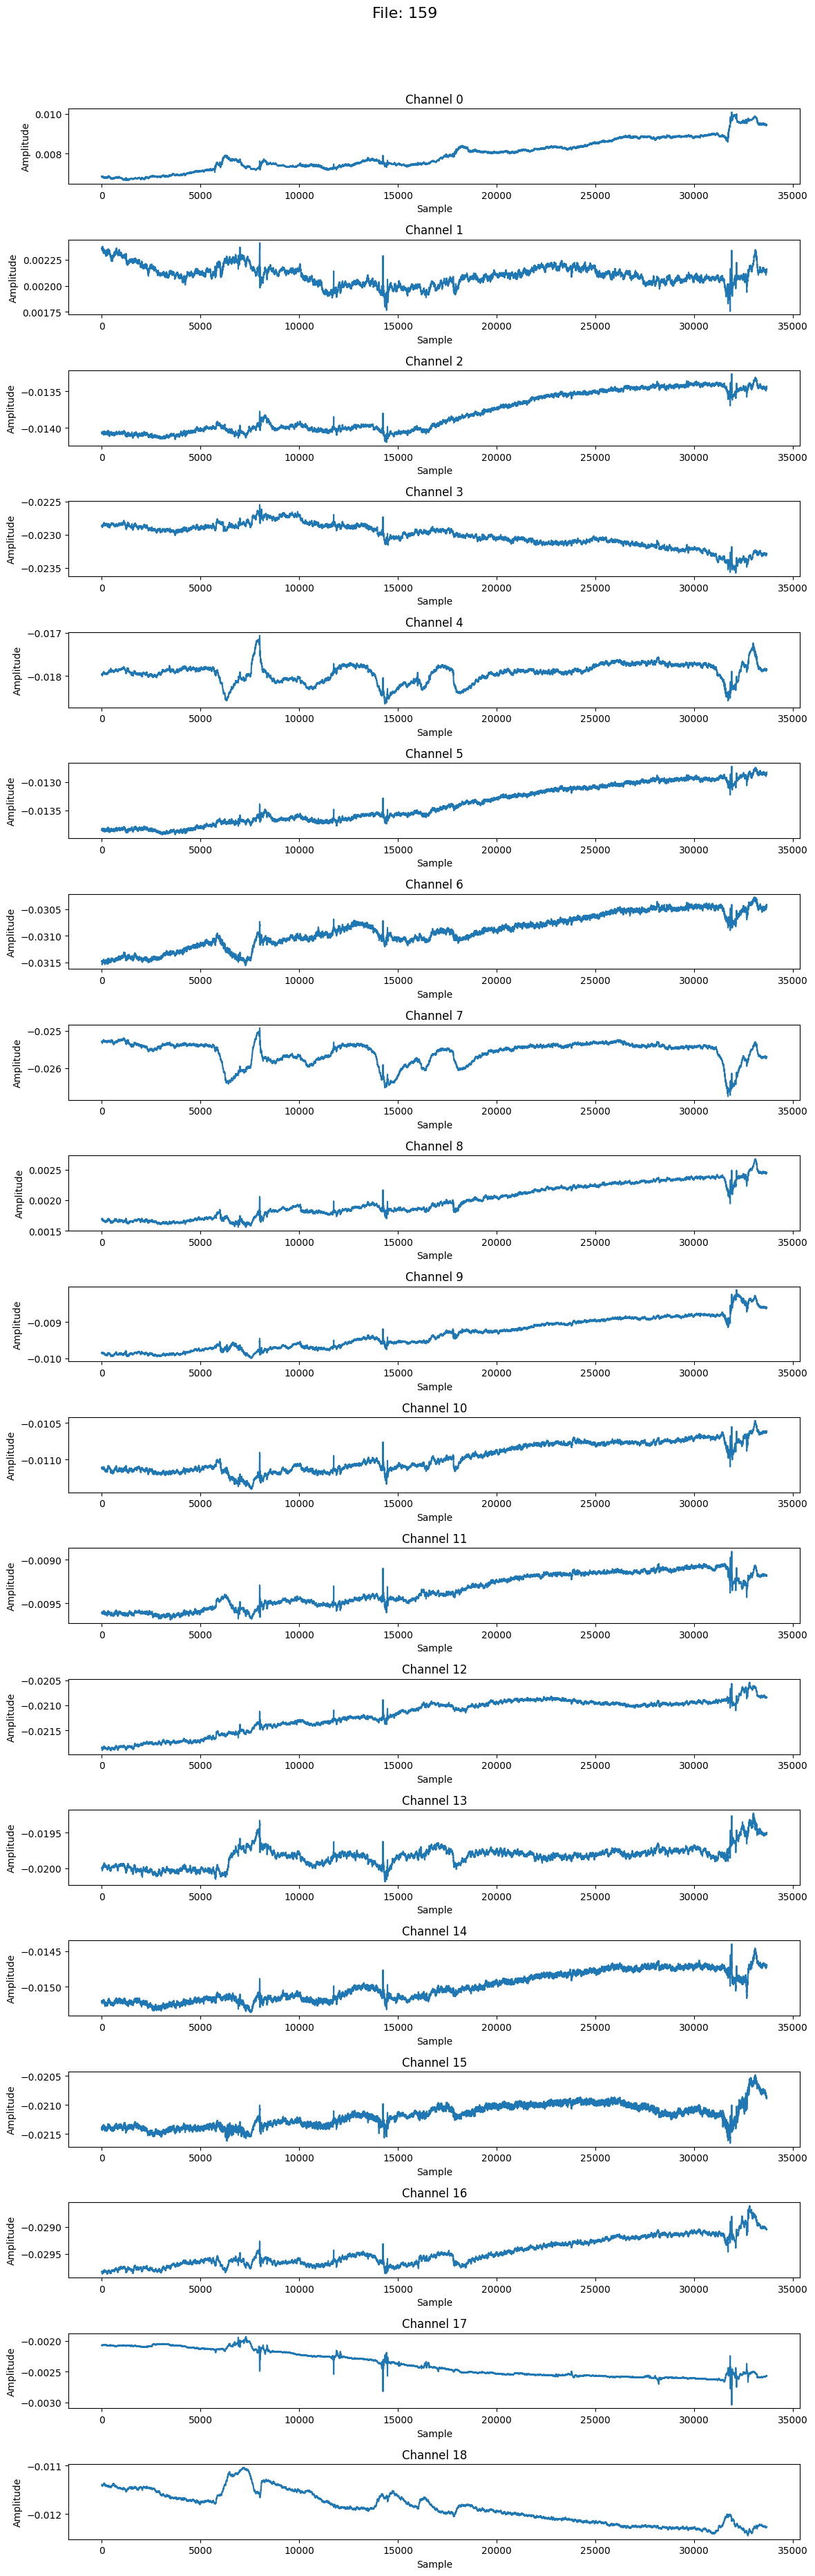

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os


file_path = "/Users/wachiii/Workschii/brain-asd/data/data_dryad_for_test/rawData/asd/159.npy"
file_name = os.path.basename(file_path)
fname, _ = os.path.splitext(file_name)
sampling_rate = 500  # adjust if needed

signals = np.load(file_path, allow_pickle=True)
if isinstance(signals, list):
    signals = np.array(signals)

n_channels = signals.shape[0] if signals.ndim > 1 else 1
length = signals.shape[1] if signals.ndim > 1 else signals.shape[0]
duration_min = length / sampling_rate / 60

print(f"File: {fname}")
print(f"Channels: {n_channels}")
print(f"Length: {length} samples")
print(f"Duration: {duration_min:.2f} minutes")

plt.figure(figsize=(12, 2 * n_channels))
plt.suptitle(f"File: {fname}", fontsize=16)
for i in range(n_channels):
    plt.subplot(n_channels, 1, i + 1)
    plt.plot(signals[i] if n_channels > 1 else signals)
    plt.title(f"Channel {i}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
plt.tight_layout(rect=[0, 0, 1, 0.96])

output_dir = "/Users/wachiii/Workschii/AllASDDataset/dryadASD/asd_plot"
os.makedirs(output_dir, exist_ok=True)
png_path = os.path.join(output_dir, f"{os.path.splitext(fname)[0]}.png")
plt.savefig(png_path, dpi=300)
print(f"Plot saved as {png_path}")
plt.show()

In [4]:
import pandas as pd
import ast

df = pd.read_excel("/Users/wachiii/Workschii/brain-asd/data/transfer_entropy/transfer_entropy_results_912_hc.xlsx")

# Columns to process
cols = ["TE list (without gaussian noise)", "TE list (with gaussian noise)"]

def parse_list(s):
    if pd.isna(s):
        return []
    # Replace np.float64 with nothing, then eval
    s = s.replace("np.float64", "")
    s = s.replace("(", "").replace(")", "")
    # Now s is like: [0.123, 0.456, ...]
    return [float(x) for x in ast.literal_eval(s)]

# Clean the columns
for col in cols:
    df[col] = df[col].apply(parse_list)

# Save cleaned version
# df.to_excel("cleaned_file.xlsx", index=False)

# Check if all lists have the same length
list_lens = df[cols[0]].apply(len)
if list_lens.nunique() == 1:
    n_subs = list_lens.iloc[0]
    for i in range(n_subs):
        df[f"Sub-{i+1} (without noise)"] = df["TE list (without gaussian noise)"].apply(lambda x: x[i] if len(x) > i else None)
        df[f"Sub-{i+1} (with noise)"] = df["TE list (with gaussian noise)"].apply(lambda x: x[i] if len(x) > i else None)
    # Save with sub-columns
    df.to_excel("transfer_entropy_age9-12_hc.xlsx", index=False)

print("Done!")

Done!
